# National distance-to-shoreline grid: tile plan and run-time estimate

**Goal (not run yet):** apply the method from `coastal_distance_methods.ipynb` / `coastal_distance_mosaic.ipynb` (vector dead
reckoning with halo seeding, in `shoredist.py`) to **all US coastal waters, including Alaska and Hawaii, from the shoreline out
to the 50 m depth contour**.

This notebook **plans** that run. It makes no distance rasters. It works out:

1. **Where:** the 0–50 m depth zone in US waters, from NOAA's ETOPO 2022 relief model, clipped to the US EEZ using NOAA's
   official maritime limits;
2. **Which tiles:** delivered BlueTopo tiles that touch the zone, plus BlueTopo-style 0.3° / 8 m cells wherever BlueTopo has
   no data yet;
3. **How many pixels**, for two output options: native BlueTopo resolution, or a uniform 8 m;
4. **How long, how much disk, how much memory**, calibrated on the measured 5 × 5 mosaic run;
5. a **tile manifest** (GeoPackage) that a production run can work through.

| Data | Source |
|---|---|
| Relief / depth | NOAA NCEI **ETOPO 2022** 15″, read at 1′ via NOAA CoastWatch ERDDAP (`ETOPO_2022_v1_15s`) |
| Tile scheme | NOAA OCS **BlueTopo** tile-scheme GeoPackage (AWS Open Data) |
| US waters | NOAA OCS **U.S. Maritime Limits & Boundaries** (EEZ outer limits + international boundaries) |
| Shoreline | NOAA NGS **CUSP** 5° packages (sizes only, via HTTP HEAD) |

In [1]:
import math, time, warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import pyogrio
import requests
import xarray as xr
from pyproj import Transformer
from rasterio.features import rasterize
from rasterio.transform import from_origin
from scipy import ndimage
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection

import shoredist as sd

warnings.filterwarnings("ignore")

# ---------------- what to plan ----------------
MAX_DEPTH_M        = 50      # zone = water from the shoreline out to this depth
CONNECTED_TO_SHORE = True    # True: only shallow water connected to the coast (drops isolated offshore banks)
INCLUDE_PR_USVI    = False   # territories are not in scope; flip to include Puerto Rico / USVI
CELL_DEG           = 0.3     # BlueTopo 8 m cell size (synthetic tiles use the same cells)
SYNTH_RES          = 8.0     # resolution for synthetic cells (and for the "uniform 8 m" option)
MARGIN_PX          = 4       # BlueTopo-style margin around each cell grid
ETOPO_STRIDE       = 4       # 15" x 4 = 1 arc-minute (~1.85 km) planning grid

# ---------------- measured on this machine (coastal_distance_mosaic.ipynb, Apple M4, 10 cores, 16 GB) ----------------
MEASURED = dict(px=392e6, wall_s=85.1, thread_s=563.0, threads=8,     # 25 tiles, distance computation incl. GeoTIFF writes
                index_vertices=12.18e6, index_s=7.5,                     # CUSP read + densify + KD-tree + bins
                mosaic_px=391e6, mosaic_s=29.5 + 14.1,                   # strip stitching + overviews
                tile_bytes_per_px=279e6 / 392e6,                         # deflate float32 tile GeoTIFFs
                single_tile_px=15.8e6, single_tile_s=13.6)               # one tile alone on one thread
WORKING_BYTES_PER_PX = 22    # fid int64 + distance float64 + float32 output + masks

DATA_DIR = Path("data"); OUT_DIR = Path("outputs") / "plan"; OUT_DIR.mkdir(parents=True, exist_ok=True)
BLUE, ORANGE, AQUA, INK, MUTED, LIGHT = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#8a8984", "#c9c8c2"
plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10})

## 1. Regions and relief

Each region is a lon/lat box read from ETOPO 2022 at 1′. Alaska crosses the antimeridian, so it is handled in 0–360°
longitude. Water is `z < 0`. In the **Great Lakes** the lake bed is *above* sea level, so there water and depth are measured
from each lake's mean surface elevation.

In [2]:
ERDDAP = ("https://coastwatch.pfeg.noaa.gov/erddap/griddap/ETOPO_2022_v1_15s.nc?"
          "z%5B({s}):{k}:({n})%5D%5B({w}):{k}:({e})%5D")
ETOPO_DIR = DATA_DIR / "etopo"; ETOPO_DIR.mkdir(parents=True, exist_ok=True)

def _etopo_chunk(w, s, e, n):
    p = ETOPO_DIR / f"etopo_k{ETOPO_STRIDE}_{w}_{s}_{e}_{n}.nc"
    if not p.exists():
        for attempt in range(6):                              # ERDDAP occasionally answers 503; back off and retry
            r = requests.get(ERDDAP.format(s=s, n=n, w=w, e=e, k=ETOPO_STRIDE), timeout=600)
            if r.ok:
                break
            time.sleep(5 * (attempt + 1))
        r.raise_for_status()
        p.write_bytes(r.content)
    return xr.open_dataset(p).z.load()

def etopo_box(w, s, e, n):
    # Fetch 10-degree-aligned chunks (cached), mosaic them, crop to the box.
    rows = []
    for s0 in range(int(math.floor(s / 10) * 10), int(math.ceil(n / 10) * 10), 10):
        cols = [_etopo_chunk(w0, s0, min(w0 + 10, 179.99), s0 + 10)
                for w0 in range(int(math.floor(w / 10) * 10), int(math.ceil(e / 10) * 10), 10)]
        rows.append(xr.concat(cols, "longitude"))
    z = xr.concat(rows, "latitude")
    z = z.isel(latitude=~z.get_index("latitude").duplicated(), longitude=~z.get_index("longitude").duplicated())
    return z.sortby("latitude").sortby("longitude").sel(latitude=slice(s, n), longitude=slice(w, e))

# lake: (bbox, mean surface elevation m) - long-term means, IGLD85 ~ EGM2008 to well under a metre
GREAT_LAKES = {"Superior": ((-92.3, 46.3, -84.3, 49.1), 183.4), "Michigan": ((-88.1, 41.6, -84.7, 46.2), 176.4),
               "Huron": ((-84.8, 43.0, -79.6, 46.4), 176.4), "St. Clair": ((-82.95, 42.3, -82.3, 42.8), 175.0),
               "Erie": ((-83.6, 41.3, -78.8, 42.95), 174.3), "Ontario": ((-80.0, 43.1, -75.9, 44.3), 74.8)}

# seed points known to be in US waters (lon, lat): the flood fill grows US waters from these
REGIONS = {
    "CONUS + Great Lakes": dict(parts=[(-125.5, 23.5, -66.5, 49.6)], lon360=False, include=True,
        seeds=[(-79.8, 26.0), (-90.0, 28.8), (-123.5, 37.5), (-122.45, 47.7), (-70.0, 42.5), (-75.5, 36.5),
               (-87.5, 47.6), (-87.0, 43.5), (-83.0, 44.8), (-82.7, 42.45), (-81.8, 41.7), (-77.0, 43.4)]),
    "Alaska": dict(parts=[(165.0, 50.5, 179.99, 75.5), (-180.0, 50.5, -129.0, 75.5)], lon360=True, include=True,
        seeds=[(-150.5, 58.5), (-165.0, 58.0), (-168.0, 70.0), (-150.0, 71.0), (-135.5, 56.5), (178.0, 51.6)]),
    "Hawaii": dict(parts=[(-179.5, 18.0, -154.0, 29.0)], lon360=False, include=True,
        seeds=[(-157.9, 21.1), (-171.7, 25.5), (-177.4, 28.2)]),
    "Puerto Rico & USVI": dict(parts=[(-68.5, 17.0, -64.0, 19.5)], lon360=False, include=INCLUDE_PR_USVI,
        seeds=[(-66.0, 18.6), (-64.8, 18.2)]),
}

class Grid:
    # North-up 1' grid for one region, with lon in -180..180 or 0..360.
    def __init__(self, name, cfg):
        parts = []
        for (w, s, e, n) in cfg["parts"]:
            z = etopo_box(w, s, e, n)
            if cfg["lon360"]:
                z = z.assign_coords(longitude=np.where(z.longitude < 0, z.longitude + 360, z.longitude))
            parts.append(z)
        z = xr.concat(parts, "longitude").sortby("longitude")
        z = z.isel(longitude=~z.get_index("longitude").duplicated())
        self.name, self.cfg, self.lon360 = name, cfg, cfg["lon360"]
        self.lon = z.longitude.values.astype(np.float64)
        self.lat = z.latitude.values[::-1].astype(np.float64)        # north -> south
        self.z = z.values[::-1].astype(np.float32)
        self.d = float(np.median(np.diff(self.lon)))
        self.transform = from_origin(self.lon[0] - self.d / 2, self.lat[0] + self.d / 2, self.d, self.d)

    def to_local_lon(self, lon):
        lon = np.asarray(lon, dtype=np.float64)
        return np.where(lon < 0, lon + 360, lon) if self.lon360 else lon

    def rc(self, lon, lat):
        c = np.floor((self.to_local_lon(lon) - (self.lon[0] - self.d / 2)) / self.d).astype(np.int64)
        r = np.floor(((self.lat[0] + self.d / 2) - np.asarray(lat)) / self.d).astype(np.int64)
        return r, c

grids = {}
for name, cfg in REGIONS.items():
    if cfg["include"]:
        t0 = time.perf_counter(); grids[name] = Grid(name, cfg)
        print(f"{name:22s} {grids[name].z.shape[0]:5d} x {grids[name].z.shape[1]:5d} cells  ({time.perf_counter()-t0:.1f}s)")

CONUS + Great Lakes     1567 x  3540 cells  (0.1s)
Alaska                  1500 x  3960 cells  (0.1s)
Hawaii                   660 x  1530 cells  (0.0s)


## 2. The 0–50 m zone in US waters

1. **Water and depth:** depth is `-z` in the ocean and `lake level − z` in the Great Lakes.
2. **US waters:** burn the EEZ outer limits and international maritime boundaries (US/Canada, Mexico, Cuba, Bahamas, Russia,
   BVI, …) into the grid as barriers, then flood-fill water outward from the seed points. The 12 nm and 24 nm lines are left
   out because they are internal to US waters. This stops the zone from leaking into foreign waters, for example the
   Great Bahama Bank or the Russian side of the shallow Chukchi Sea.
3. **Zone:** US water with depth ≤ `MAX_DEPTH_M`, optionally only the parts connected to a shore.

In [3]:
mlb = pyogrio.read_dataframe("/vsizip/" + str(sd.fetch(
    "https://maritimeboundaries.noaa.gov/downloads/USMaritimeLimitsAndBoundariesSHP.zip",
    DATA_DIR / "maritime" / "USMaritimeLimitsAndBoundariesSHP.zip")) + "/USMaritimeLimitsNBoundaries.shp")
barrier_lines = mlb[(mlb.EEZ == 1) | mlb.FEAT_TYPE.isin(["Maritime Boundary", "Land Boundary"])]
print(f"{len(barrier_lines)} barrier lines (EEZ limits + boundaries) of {len(mlb)} maritime-limit features")

def to360(g):
    return shapely.transform(g, lambda c: np.column_stack([np.where(c[:, 0] < 0, c[:, 0] + 360, c[:, 0]), c[:, 1]]))

def build_zone(G):
    z = G.z
    water = z < 0
    depth = np.where(water, -z, np.nan).astype(np.float32)
    lake = np.zeros_like(water)
    if G.name.startswith("CONUS"):
        LON, LAT = np.meshgrid(G.lon, G.lat)
        for (w, s, e, n), level in GREAT_LAKES.values():
            box = (LON >= w) & (LON <= e) & (LAT >= s) & (LAT <= n) & (z < level - 0.3) & (z > level - 450)
            lake |= box
            depth = np.where(box, level - z, depth)
        water |= lake
    geoms = barrier_lines.geometry.values
    if G.lon360:
        geoms = np.array([to360(g) for g in geoms])
    barrier = rasterize(((g, 1) for g in geoms), out_shape=z.shape, transform=G.transform,
                        all_touched=True, dtype="uint8").astype(bool)
    lab, _ = ndimage.label(water & ~barrier)                      # 4-connected: a 1-cell barrier seals
    seed_labels = set()
    for lon, lat in G.cfg["seeds"]:
        r, c = G.rc(lon, lat); r, c = int(r), int(c)
        win = lab[max(0, r - 30):r + 31, max(0, c - 30):c + 31]
        ii, jj = np.nonzero(win)
        if not len(ii):
            raise ValueError(f"seed {lon, lat} has no water nearby")
        k = np.argmin((ii - min(r, 30)) ** 2 + (jj - min(c, 30)) ** 2)
        seed_labels.add(int(win[ii[k], jj[k]]))
    us_water = np.isin(lab, list(seed_labels))
    shallow = us_water & (depth <= MAX_DEPTH_M)
    coast = water & ~ndimage.binary_erosion(water, border_value=1)   # water cells touching land
    if CONNECTED_TO_SHORE:
        zl, _ = ndimage.label(shallow, structure=np.ones((3, 3)))
        keep = np.unique(zl[shallow & coast]); keep = keep[keep > 0]
        zone = np.isin(zl, keep)
    else:
        zone = shallow
    return dict(water=water, lake=lake, barrier=barrier, us_water=us_water, shallow=shallow, zone=zone, depth=depth)

R = 6371.0088
def cell_area_km2(G):
    return (R * math.radians(G.d)) ** 2 * np.cos(np.radians(G.lat))[:, None]

Z = {}
for name, G in grids.items():
    t0 = time.perf_counter(); Z[name] = build_zone(G)
    A = np.broadcast_to(cell_area_km2(G), G.z.shape)
    zr = Z[name]
    print(f"{name:22s} zone {A[zr['zone']].sum():>10,.0f} km²   (all shallow US water {A[zr['shallow']].sum():>10,.0f} km², "
          f"US water {A[zr['us_water']].sum():>12,.0f} km²)  {time.perf_counter()-t0:.1f}s")

110 barrier lines (EEZ limits + boundaries) of 260 maritime-limit features


CONUS + Great Lakes    zone    507,070 km²   (all shallow US water    517,602 km², US water    2,255,704 km²)  0.2s
Alaska                 zone    580,248 km²   (all shallow US water    584,947 km², US water    3,321,009 km²)  0.1s
Hawaii                 zone      8,072 km²   (all shallow US water     11,184 km², US water    1,882,823 km²)  0.0s


In [4]:
# How far from land does the zone reach? This sets the shoreline search buffer (and KD-tree cost) per region.
def to_xyz(lon, lat):
    lo, la = np.radians(lon), np.radians(lat)
    return np.column_stack([np.cos(la) * np.cos(lo), np.cos(la) * np.sin(lo), np.sin(la)])

for name, G in grids.items():
    zr = Z[name]
    land = ~zr["water"]
    shore_land = land & ndimage.binary_dilation(zr["water"])        # land cells touching water
    LON, LAT = np.meshgrid(G.lon, G.lat)
    tree = cKDTree(to_xyz(LON[shore_land], LAT[shore_land]))
    chord = tree.query(to_xyz(LON[zr["zone"]], LAT[zr["zone"]]), workers=-1)[0]
    dist_km = 2 * R * np.arcsin(np.clip(chord / 2, 0, 1))
    zr["dist_km"] = np.full(G.z.shape, np.nan, np.float32); zr["dist_km"][zr["zone"]] = dist_km
    print(f"{name:22s} distance to land inside the zone: median {np.median(dist_km):6.1f} km, "
          f"p99 {np.percentile(dist_km, 99):6.1f} km, max {dist_km.max():6.1f} km")

CONUS + Great Lakes    distance to land inside the zone: median   21.4 km, p99  120.5 km, max  151.2 km


Alaska                 distance to land inside the zone: median   48.5 km, p99  246.7 km, max  291.0 km
Hawaii                 distance to land inside the zone: median    7.5 km, p99   25.5 km, max   27.4 km


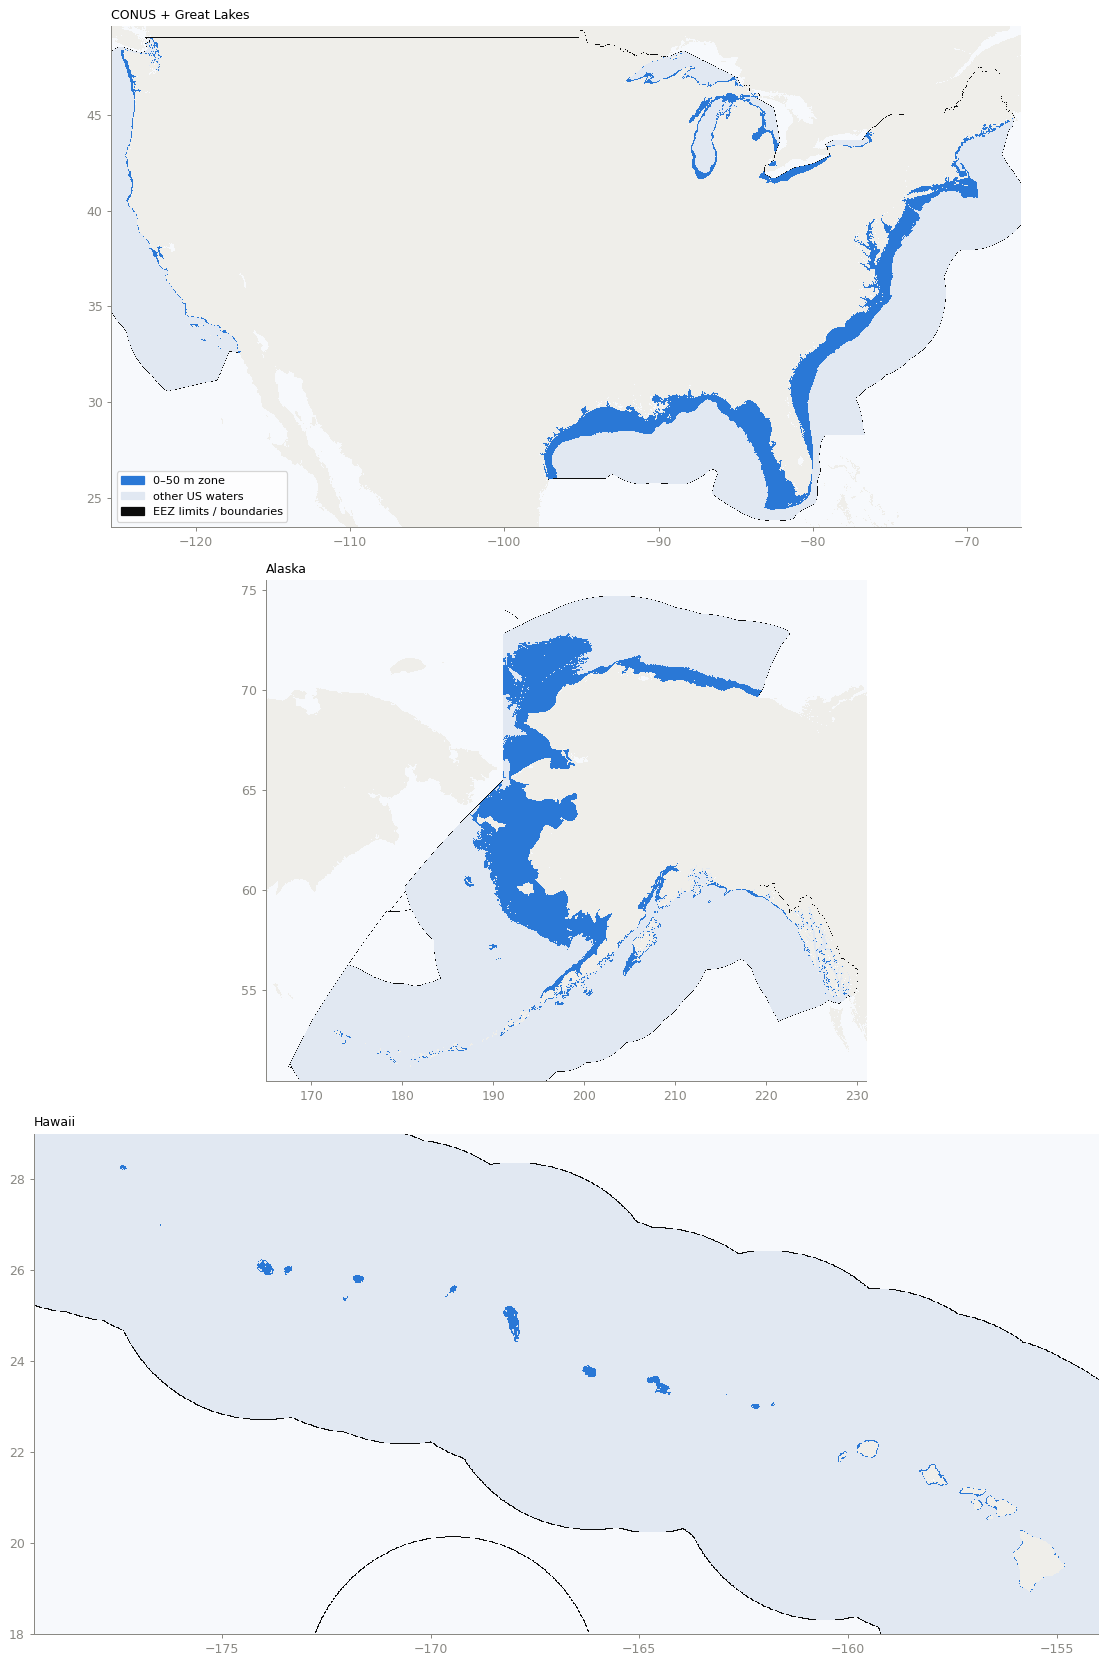

In [5]:
def show_region(ax, G, zr, title, extra=None):
    ext = (G.lon[0] - G.d / 2, G.lon[-1] + G.d / 2, G.lat[-1] - G.d / 2, G.lat[0] + G.d / 2)
    layer = lambda m: np.ma.masked_where(~m, np.ones(m.shape))
    ax.imshow(np.where(zr["water"], 1.0, 0.0), extent=ext, cmap=mcolors.ListedColormap(["#efeeea", "#f7f9fc"]),
              interpolation="nearest")
    for m, color in ((zr["us_water"] & ~zr["zone"], "#e1e8f2"), (zr["zone"], BLUE), (zr["barrier"], INK)):
        ax.imshow(layer(m), extent=ext, cmap=mcolors.ListedColormap([color]), interpolation="nearest")
    if extra:
        extra(ax)
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
    ax.set_aspect(1 / math.cos(math.radians(np.mean(G.lat))))
    ax.set_title(title, loc="left", fontsize=10)

legend = [mpatches.Patch(color=BLUE, label=f"0–{MAX_DEPTH_M} m zone"), mpatches.Patch(color="#e1e8f2", label="other US waters"),
          mpatches.Patch(color=INK, label="EEZ limits / boundaries")]
fig, axs = plt.subplots(len(grids), 1, figsize=(13, 6.2 * len(grids)))
for ax, (name, G) in zip(np.atleast_1d(axs), grids.items()):
    show_region(ax, G, Z[name], name)
np.atleast_1d(axs)[0].legend(handles=legend, loc="lower left", frameon=True, fontsize=9)
plt.tight_layout(); plt.show()

## 3. Which tiles?

**Delivered BlueTopo tiles:** every tile with a GeoTIFF that overlaps the zone. A tile is computed as a whole, on its own grid.

**Synthetic tiles:** the tile scheme also lists about 3,900 placeholder tiles with no data yet. And BlueTopo currently has
**no tiles at all in Hawaii, or in Alaska west of about 138° W**. A distance field needs only a grid, not bathymetry, so where the
zone is not covered by a delivered tile we use BlueTopo's own **0.3° cell** pattern at 8 m, on the same UTM pixel lattice as
the real 8 m tiles (as in the mosaic notebook). When BlueTopo later delivers those tiles, those cells can be recomputed on the real grids.

In [6]:
scheme = gpd.read_file(sd.latest_tile_scheme(DATA_DIR))
delivered = scheme[scheme.Resolution.notna() & scheme.GeoTIFF_Link.notna()].copy()
placeholders = scheme[scheme.Resolution.isna()]
b = delivered.geometry.bounds
delivered["lon0"], delivered["lat0"], delivered["lon1"], delivered["lat1"] = b.minx, b.miny, b.maxx, b.maxy
delivered["res"] = delivered.Resolution.str.rstrip("m").astype(float)
delivered["utm"] = delivered.UTM.astype(int)
print(f"tile scheme: {len(scheme):,} tiles = {len(delivered):,} delivered + {len(placeholders):,} placeholders (no data yet)")

def sat(mask):
    # summed-area table with a zero row/col, for O(1) box counts
    S = np.zeros((mask.shape[0] + 1, mask.shape[1] + 1), np.int64)
    S[1:, 1:] = mask.cumsum(0).cumsum(1)
    return S

def box_counts(G, S, lon0, lat0, lon1, lat1):
    # number of grid cells whose centre lies inside each lon/lat box
    l0, l1 = G.to_local_lon(lon0), G.to_local_lon(lon1)
    l1 = np.where(l1 < l0, l1 + 360, l1)
    c0 = np.clip(np.ceil((l0 - G.lon[0]) / G.d - 1e-9).astype(int), 0, len(G.lon))
    c1 = np.clip(np.floor((l1 - G.lon[0]) / G.d + 1e-9).astype(int) + 1, 0, len(G.lon))
    r0 = np.clip(np.ceil((G.lat[0] - np.asarray(lat1)) / G.d - 1e-9).astype(int), 0, len(G.lat))
    r1 = np.clip(np.floor((G.lat[0] - np.asarray(lat0)) / G.d + 1e-9).astype(int) + 1, 0, len(G.lat))
    c1 = np.maximum(c1, c0); r1 = np.maximum(r1, r0)
    return S[r1, c1] - S[r0, c1] - S[r1, c0] + S[r0, c0], (r0, r1, c0, c1)

def in_region(G, lon, lat):
    l = G.to_local_lon(lon)
    return (l >= G.lon[0]) & (l <= G.lon[-1]) & (lat >= G.lat[-1]) & (lat <= G.lat[0])

sel_parts, synth_parts = [], []
for name, G in grids.items():
    zr = Z[name]
    S_zone = sat(zr["zone"])
    cx, cy = (delivered.lon0 + delivered.lon1) / 2, (delivered.lat0 + delivered.lat1) / 2
    d = delivered[in_region(G, cx.values, cy.values)].copy()
    n, (r0, r1, c0, c1) = box_counts(G, S_zone, d.lon0.values, d.lat0.values, d.lon1.values, d.lat1.values)
    d["zone_cells"] = n
    d = d[d.zone_cells > 0].copy(); d["region"] = name; d["source"] = "BlueTopo (delivered)"
    sel_parts.append(d)
    covered = np.zeros(G.z.shape, bool)                     # zone cells already covered by a delivered tile
    _, (r0, r1, c0, c1) = box_counts(G, S_zone, d.lon0.values, d.lat0.values, d.lon1.values, d.lat1.values)
    for a, bb, cc, dd in zip(r0, r1, c0, c1):
        covered[a:bb, cc:dd] = True
    gap = zr["zone"] & ~covered
    zr["covered"], zr["gap"] = covered, gap
    # synthetic 0.3-degree cells over the gap
    S_gap = sat(gap)
    w = math.floor((G.lon[0]) / CELL_DEG) * CELL_DEG; e = G.lon[-1]
    s_ = math.floor(G.lat[-1] / CELL_DEG) * CELL_DEG; n_ = G.lat[0]
    lons = np.round(np.arange(w, e, CELL_DEG), 4); lats = np.round(np.arange(s_, n_, CELL_DEG), 4)
    L0, A0 = [a.ravel() for a in np.meshgrid(lons, lats)]
    L0 = np.where(L0 >= 180, L0 - 360, L0)                   # back to -180..180 for naming / UTM
    L1 = np.round(L0 + CELL_DEG, 4)
    gcount, _ = box_counts(G, S_gap, L0, A0, L1, A0 + CELL_DEG)
    zcount, _ = box_counts(G, S_zone, L0, A0, L1, A0 + CELL_DEG)
    m = gcount > 0
    syn = pd.DataFrame(dict(lon0=L0[m], lat0=A0[m], lon1=L1[m], lat1=np.round(A0[m] + CELL_DEG, 4),
                            zone_cells=zcount[m], gap_cells=gcount[m]))
    syn["tile"] = [f"S8_{'N' if a >= 0 else 'S'}{abs(a):05.2f}_{'E' if o >= 0 else 'W'}{abs(o):06.2f}"
                   for a, o in zip(syn.lat0, syn.lon0)]
    syn["res"] = SYNTH_RES; syn["region"] = name; syn["source"] = "synthetic 0.3° cell"
    syn["utm"] = (np.floor((syn.lon0 + CELL_DEG / 2 + 180) / 6) + 1).astype(int)
    synth_parts.append(syn)
    A = np.broadcast_to(cell_area_km2(G), G.z.shape)
    print(f"{name:22s} delivered tiles touching zone: {len(d):6,}   synthetic cells: {len(syn):6,}   "
          f"zone covered by delivered tiles: {100 * A[zr['zone'] & covered].sum() / A[zr['zone']].sum():5.1f}%")

cols = ["tile", "region", "source", "res", "utm", "lon0", "lat0", "lon1", "lat1", "zone_cells"]
plan = pd.concat([pd.concat(sel_parts)[cols], pd.concat(synth_parts)[cols]], ignore_index=True)
plan.groupby(["region", "source", "res"]).size().unstack("res", fill_value=0)

tile scheme: 12,638 tiles = 8,689 delivered + 3,949 placeholders (no data yet)
CONUS + Great Lakes    delivered tiles touching zone:  4,145   synthetic cells:    327   zone covered by delivered tiles:  87.7%
Alaska                 delivered tiles touching zone:    990   synthetic cells:  1,990   zone covered by delivered tiles:   1.3%
Hawaii                 delivered tiles touching zone:      0   synthetic cells:     82   zone covered by delivered tiles:   0.0%


res                                       2.0   4.0   8.0   16.0
region              source                                      
Alaska              BlueTopo (delivered)     0   985     0     5
                    synthetic 0.3° cell      0     0  1990     0
CONUS + Great Lakes BlueTopo (delivered)    14  3702   387    42
                    synthetic 0.3° cell      0     0   327     0
Hawaii              synthetic 0.3° cell      0     0    82     0

## 4. Pixels per tile

A tile's grid is the UTM bounding box of its lon/lat cell, snapped to the pixel lattice, plus a small margin. Its pixel count is
that box's area divided by the pixel area. We check this rule against the 18 real 8 m tiles downloaded for the mosaic notebook.

In [7]:
def utm_grid_shape(lon0, lat0, lon1, lat1, zone, res, n_edge=24):
    # rows, cols of the UTM-aligned grid covering each lon/lat box (vectorised for one zone)
    epsg = 32600 + int(zone)
    tr = Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True)
    t = np.linspace(0, 1, n_edge)
    lon0, lat0, lon1, lat1 = map(np.asarray, (lon0, lat0, lon1, lat1))
    lon1 = np.where(lon1 < lon0, lon1 + 360, lon1)
    ex = np.concatenate([lon0[:, None] + (lon1 - lon0)[:, None] * t, np.repeat(lon1[:, None], n_edge, 1),
                         lon1[:, None] - (lon1 - lon0)[:, None] * t, np.repeat(lon0[:, None], n_edge, 1)], 1)
    ey = np.concatenate([np.repeat(lat0[:, None], n_edge, 1), lat0[:, None] + (lat1 - lat0)[:, None] * t,
                         np.repeat(lat1[:, None], n_edge, 1), lat1[:, None] - (lat1 - lat0)[:, None] * t], 1)
    ex = np.where(ex > 180, ex - 360, ex)
    x, y = tr.transform(ex, ey)
    W = np.ceil((x.max(1) - x.min(1)) / res) + 1 + 2 * MARGIN_PX
    H = np.ceil((y.max(1) - y.min(1)) / res) + 1 + 2 * MARGIN_PX
    return H.astype(np.int64), W.astype(np.int64)

# validate against the real 8 m tiles on disk
import rasterio, glob
chk = []
for p in sorted(glob.glob(str(DATA_DIR / "bluetopo" / "BlueTopo_BF2G*.tiff"))):
    t = Path(p).name.split("_")[1]
    row = delivered[delivered.tile == t].iloc[0]
    H, W = utm_grid_shape([row.lon0], [row.lat0], [row.lon1], [row.lat1], row.utm, row.res)
    with rasterio.open(p) as ds:
        chk.append(dict(tile=t, actual_px=ds.width * ds.height, predicted_px=int(H[0] * W[0])))
chk = pd.DataFrame(chk); chk["ratio"] = chk.predicted_px / chk.actual_px
print(f"pixel-count rule vs {len(chk)} real tiles: predicted/actual = {chk.ratio.mean():.4f} "
      f"(range {chk.ratio.min():.4f}–{chk.ratio.max():.4f})")

plan["px_native"] = 0; plan["px_8m"] = 0
for zone, idx in plan.groupby("utm").groups.items():
    p = plan.loc[idx]
    H, W = utm_grid_shape(p.lon0.values, p.lat0.values, p.lon1.values, p.lat1.values, zone, 1.0)
    area = ((H - 1 - 2 * MARGIN_PX) * (W - 1 - 2 * MARGIN_PX)).astype(float)    # m² of the UTM bbox
    for col, res in (("px_native", p.res.values), ("px_8m", np.full(len(p), 8.0))):
        side_h = (H - 1 - 2 * MARGIN_PX) / res + 1 + 2 * MARGIN_PX
        side_w = (W - 1 - 2 * MARGIN_PX) / res + 1 + 2 * MARGIN_PX
        plan.loc[idx, col] = (np.ceil(side_h) * np.ceil(side_w)).astype(np.int64)
plan["px_native"] = plan.px_native.astype(np.int64); plan["px_8m"] = plan.px_8m.astype(np.int64)
print(f"{len(plan):,} tiles | native resolution: {plan.px_native.sum()/1e9:,.1f} Gpx | uniform 8 m: {plan.px_8m.sum()/1e9:,.1f} Gpx")

pixel-count rule vs 18 real tiles: predicted/actual = 1.0007 (range 1.0005–1.0010)


7,534 tiles | native resolution: 45.5 Gpx | uniform 8 m: 39.3 Gpx


In [8]:
summary = (plan.assign(res=plan.res.map(lambda r: f"{r:g} m"))
           .groupby(["region", "source", "res"])
           .agg(tiles=("tile", "size"), Gpx_native=("px_native", lambda s: s.sum() / 1e9),
                Gpx_8m=("px_8m", lambda s: s.sum() / 1e9), largest_tile_Mpx=("px_native", lambda s: s.max() / 1e6)))
tot = summary.sum(numeric_only=True); tot["largest_tile_Mpx"] = summary.largest_tile_Mpx.max()
summary.loc[("TOTAL", "", ""), :] = tot
summary.style.format({"tiles": "{:,.0f}", "Gpx_native": "{:,.2f}", "Gpx_8m": "{:,.2f}", "largest_tile_Mpx": "{:,.0f}"})

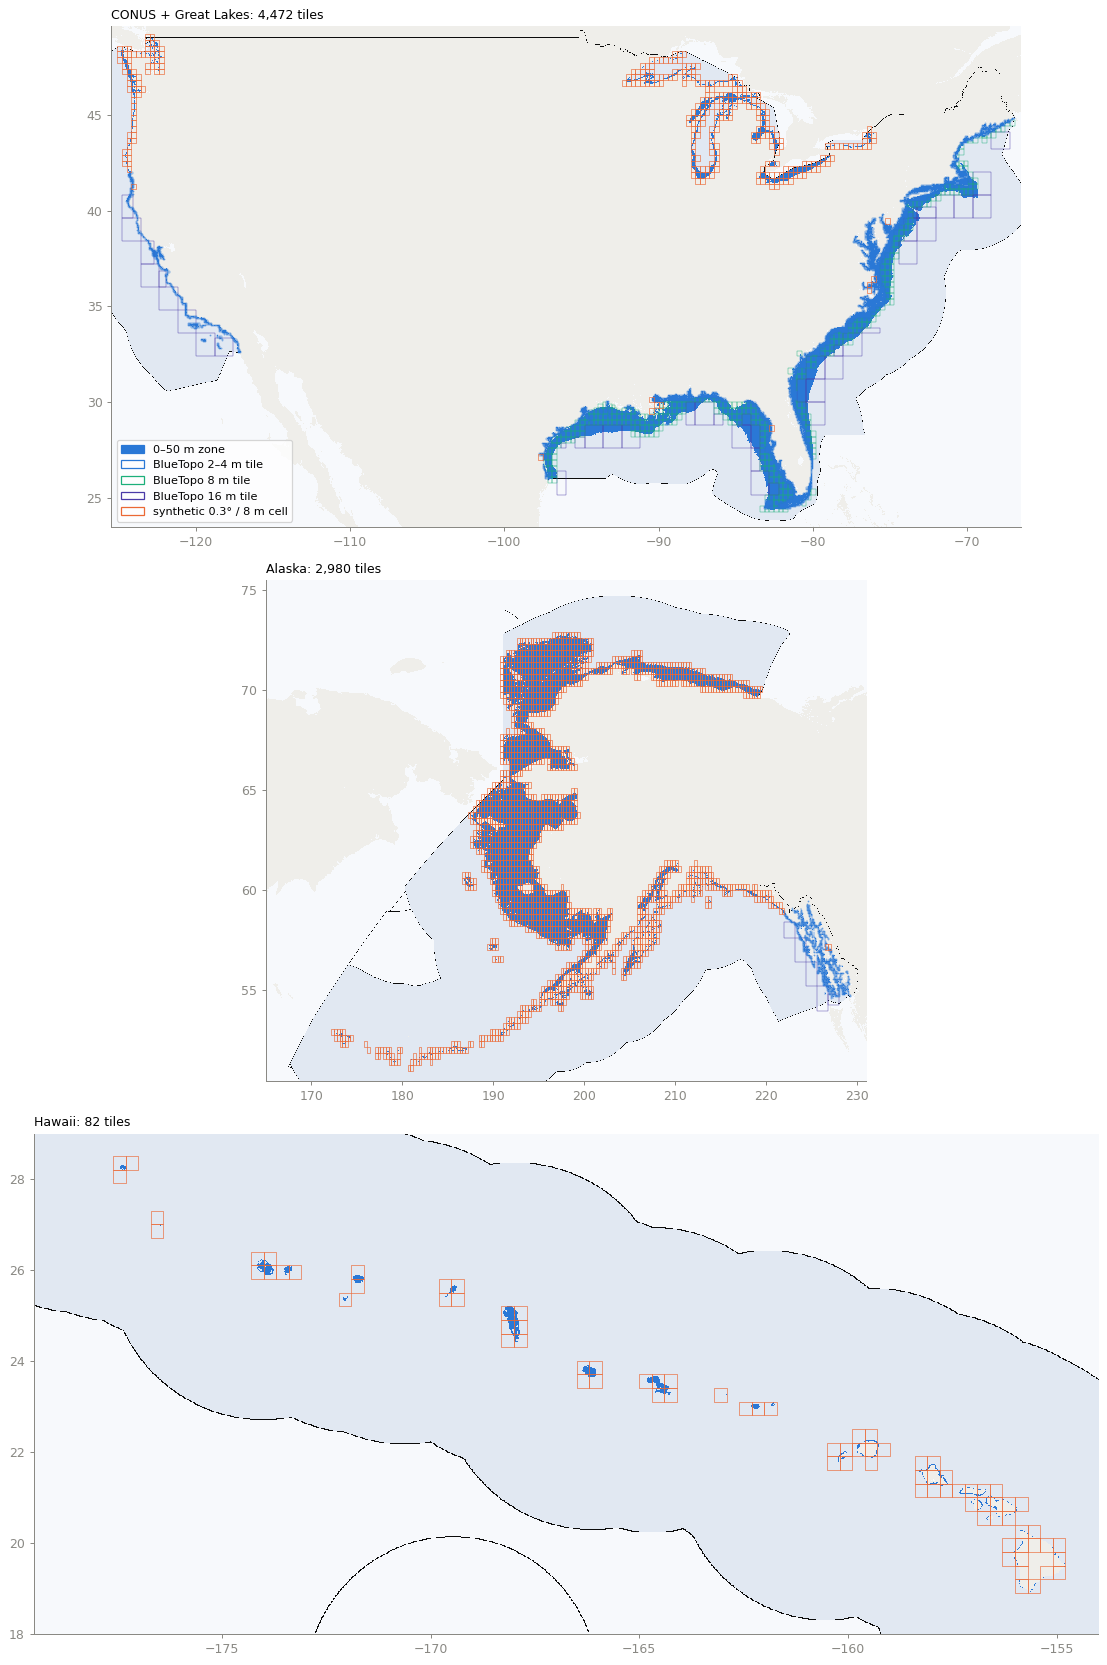

In [9]:
# Maps: selected tiles over the zone
RES_COLORS = {2.0: BLUE, 4.0: BLUE, 8.0: AQUA, 16.0: "#4a3aa7"}
def tile_patches(ax, G, df):
    for src, ls in (("BlueTopo (delivered)", "-"), ("synthetic 0.3° cell", "-")):
        sub = df[df.source == src]
        rects = []
        for r in sub.itertuples():
            x0 = float(G.to_local_lon(r.lon0)); x1 = x0 + ((r.lon1 - r.lon0) % 360 or 360)
            rects.append(mpatches.Rectangle((x0, r.lat0), x1 - x0, r.lat1 - r.lat0))
        if not rects:
            continue
        if src.startswith("synthetic"):
            ax.add_collection(PatchCollection(rects, facecolor="none", edgecolor=ORANGE, lw=0.5))
        else:
            ax.add_collection(PatchCollection(rects, facecolor="none",
                                              edgecolor=[RES_COLORS[r] for r in sub.res], lw=0.35))

fig, axs = plt.subplots(len(grids), 1, figsize=(13, 6.2 * len(grids)))
for ax, (name, G) in zip(np.atleast_1d(axs), grids.items()):
    df = plan[plan.region == name]
    show_region(ax, G, Z[name], f"{name}: {len(df):,} tiles", extra=lambda a, G=G, df=df: tile_patches(a, G, df))
np.atleast_1d(axs)[0].legend(handles=[mpatches.Patch(color=BLUE, label=f"0–{MAX_DEPTH_M} m zone"),
    mpatches.Patch(fc="none", ec=BLUE, label="BlueTopo 2–4 m tile"), mpatches.Patch(fc="none", ec=AQUA, label="BlueTopo 8 m tile"),
    mpatches.Patch(fc="none", ec="#4a3aa7", label="BlueTopo 16 m tile"), mpatches.Patch(fc="none", ec=ORANGE, label="synthetic 0.3° / 8 m cell")],
    loc="lower left", frameon=True, fontsize=9)
plt.tight_layout(); plt.savefig(OUT_DIR / "plan_tiles_map.png", dpi=110, bbox_inches="tight"); plt.show()

## 5. Inputs to download

* **CUSP shoreline:** the 5° packages under the selected tiles plus one ring of neighbours (the search buffer). We read sizes
  with HTTP HEAD requests; nothing is downloaded here.
* **BlueTopo GeoTIFFs** are **not needed** for distances. The grids come from the tile scheme, or from a few kB of each GeoTIFF
  header read over HTTP. They are only needed if you want to mask the output with BlueTopo's own depths. Their total size is listed for reference.

In [10]:
def region_cells(df):
    names = set()
    for r in df.itertuples():
        for la in np.arange(math.floor(r.lat0 / 5) * 5 - 5, r.lat1 + 5, 5):
            for lo in np.arange(math.floor(r.lon0 / 5) * 5 - 5, r.lon1 + 5, 5):
                lo2 = lo - 360 if lo >= 180 else (lo + 360 if lo < -180 else lo)
                if lo2 < 0:                                     # CUSP names are N..W.. (western hemisphere)
                    names.add(f"N{int(la):02d}W{int(-lo2):03d}")
                else:
                    names.add(f"N{int(la):02d}E{int(lo2):03d}")
    return names

def head_size(url):
    try:
        r = requests.head(url, timeout=60, allow_redirects=True)
        return int(r.headers.get("content-length", 0)) if r.ok else 0
    except requests.RequestException:
        return 0

needed = sorted(region_cells(plan))
with ThreadPoolExecutor(16) as ex:
    sizes = dict(zip(needed, ex.map(lambda n: head_size(sd.CUSP_URL.format(name=n)), needed)))
cusp = pd.Series({k: v for k, v in sizes.items() if v > 0}, name="bytes").sort_values(ascending=False)
print(f"CUSP packages: {len(cusp)} of {len(needed)} candidate 5° cells exist, {cusp.sum()/1e9:.2f} GB to download")

dl = scheme[scheme.tile.isin(plan.tile)]
with ThreadPoolExecutor(32) as ex:
    bt_bytes = sum(ex.map(head_size, dl.GeoTIFF_Link))
print(f"BlueTopo GeoTIFFs for the {len(dl):,} delivered tiles (optional): {bt_bytes/1e9:,.1f} GB")
cusp.head(10).map(lambda b: f"{b/1e6:,.0f} MB")

CUSP packages: 69 of 183 candidate 5° cells exist, 0.96 GB to download


BlueTopo GeoTIFFs for the 5,135 delivered tiles (optional): 39.3 GB


N35W080    179 MB
N25W085    119 MB
N25W095     85 MB
N30W085     73 MB
N30W080     66 MB
N25W090     44 MB
N40W075     40 MB
N60W165     29 MB
N55W135     28 MB
N25W100     28 MB
Name: bytes, dtype: object

## 6. How long will it take?

**Calibration (measured on this Mac mini, Apple M4, 10 cores, 16 GB):** 25 tiles, 392 Mpx, 85.1 s wall on 8 threads, so
**4.6 Mpx/s**. That is 0.70 Mpx/s per thread with 8 running at once and 83% of threads busy (the end of the run leaves some idle), and 1.16 Mpx/s for one tile on its own. The time per pixel
barely depends on how far the pixel is from shore or how complicated the coast is (the 25 tiles ranged from marsh to open Gulf
and took 19.5–24.5 s each), so **time ≈ pixels ÷ throughput**, plus:

* **shoreline index builds:** about 0.62 µs per densified vertex. Vertices are estimated from CUSP package size, scaled
  from the four packages we have measured. Each 5° region is built with its neighbours, so each package is read about 9 times;
* **downloads:** CUSP at an assumed 25 MB/s;
* **optional mosaics:** strip stitching plus overviews at the measured 9 Mpx/s.
* **the slowest tile:** wall time can never be shorter than the largest tile on one thread. This sets the floor for big clusters.

**Memory:** about 22 bytes per pixel while a tile is being computed. With 8 threads on 16 GB, tiles above about 70 Mpx
(1.2° 16 m tiles at native resolution, or 0.3° cells at 4 m) need fewer threads at once. The schedule below accounts for this.

**Other machines** are an **assumption** to calibrate. Throughput scales with cores: one x86 vCPU is assumed to give about 0.45 Mpx/s
(two-thirds of an M4 performance core). Run the calibration cell at the end on the target machine to replace the assumption.

In [11]:
per_thread = MEASURED["px"] / MEASURED["thread_s"]                   # px/s per busy thread under load
EFFICIENCY = MEASURED["thread_s"] / (MEASURED["wall_s"] * MEASURED["threads"])   # 0.83: idle threads in the tail
s_per_vertex = MEASURED["index_s"] / MEASURED["index_vertices"]
# vertices per CUSP zip byte, from the 4 measured Gulf packages: 24.3 M native vertices in 256 MB of zips, x1.8 densify
vert_per_byte = 24.3e6 * 1.8 / 256e6
index_s = (cusp.sum() * 9) * vert_per_byte * s_per_vertex            # each package read with its 8 neighbours
download_s = cusp.sum() / 25e6
mosaic_rate = MEASURED["mosaic_px"] / MEASURED["mosaic_s"]

MACHINES = [  # name, worker threads, px/s per thread, RAM GB, basis
    ("This Mac mini (M4, 16 GB)", 8, per_thread, 16, "measured"),
    ("1 cloud node, 64 vCPU / 128 GB", 64, 0.45e6, 128, "assumed"),
    ("8 cloud nodes, 64 vCPU each", 512, 0.45e6, 1024, "assumed"),
]

def schedule_hours(px, threads, rate, ram_gb):
    # Tiles too big to run `threads` at once get fewer threads (memory-limited), which slows them down.
    px = np.asarray(px, dtype=float)
    max_conc = np.maximum(1, np.floor(ram_gb * 0.7e9 / (px * WORKING_BYTES_PER_PX))).clip(max=threads)
    eff_threads = np.minimum(threads, max_conc)
    total = float((px / (rate * eff_threads * EFFICIENCY)).sum())
    slowest = float(px.max() / rate)                  # wall time can never beat the largest single tile
    return max(total, slowest) / 3600, int((max_conc < threads).sum()), slowest / 3600

rows = []
for scen, col in (("native BlueTopo resolution", "px_native"), ("uniform 8 m", "px_8m")):
    px = plan[col].values
    for name, threads, rate, ram, basis in MACHINES:
        compute_h, n_limited, slowest_h = schedule_hours(px, threads, rate, ram)
        nodes = max(1, threads // 64) if "cloud" in name else 1
        rows.append({"output": scen, "machine": name, "basis": basis, "Gpx": px.sum() / 1e9,
                     "compute_h": compute_h, "index_h": index_s / 3600 / nodes, "download_h": download_s / 3600,
                     "memory_limited_tiles": n_limited, "slowest_tile_min": slowest_h * 60,
                     "tiles_GB": px.sum() * MEASURED["tile_bytes_per_px"] / 1e9,
                     "mosaic_h (optional)": px.sum() / mosaic_rate / 3600})
est = pd.DataFrame(rows)
est["total_h"] = est.compute_h + est.index_h + est.download_h
est["range_h (±30%)"] = [f"{t*0.7:,.1f} – {t*1.3:,.1f}" for t in est.total_h]
est.style.format({"Gpx": "{:,.1f}", "compute_h": "{:,.2f}", "index_h": "{:,.2f}", "download_h": "{:,.2f}",
                  "slowest_tile_min": "{:,.1f}", "tiles_GB": "{:,.0f}", "mosaic_h (optional)": "{:,.1f}", "total_h": "{:,.1f}"}).hide(axis="index")

output,machine,basis,Gpx,compute_h,index_h,download_h,memory_limited_tiles,slowest_tile_min,tiles_GB,mosaic_h (optional),total_h,range_h (±30%)
native BlueTopo resolution,"This Mac mini (M4, 16 GB)",measured,45.5,2.74,0.25,0.01,2,1.6,32,1.4,3.0,2.1 – 3.9
native BlueTopo resolution,"1 cloud node, 64 vCPU / 128 GB",assumed,45.5,0.53,0.25,0.01,2,2.4,32,1.4,0.8,0.6 – 1.0
native BlueTopo resolution,"8 cloud nodes, 64 vCPU each",assumed,45.5,0.07,0.03,0.01,2,2.4,32,1.4,0.1,0.1 – 0.1
uniform 8 m,"This Mac mini (M4, 16 GB)",measured,39.3,3.65,0.25,0.01,41,6.2,28,1.2,3.9,2.7 – 5.1
uniform 8 m,"1 cloud node, 64 vCPU / 128 GB",assumed,39.3,0.67,0.25,0.01,41,9.6,28,1.2,0.9,0.7 – 1.2
uniform 8 m,"8 cloud nodes, 64 vCPU each",assumed,39.3,0.16,0.03,0.01,41,9.6,28,1.2,0.2,0.1 – 0.3


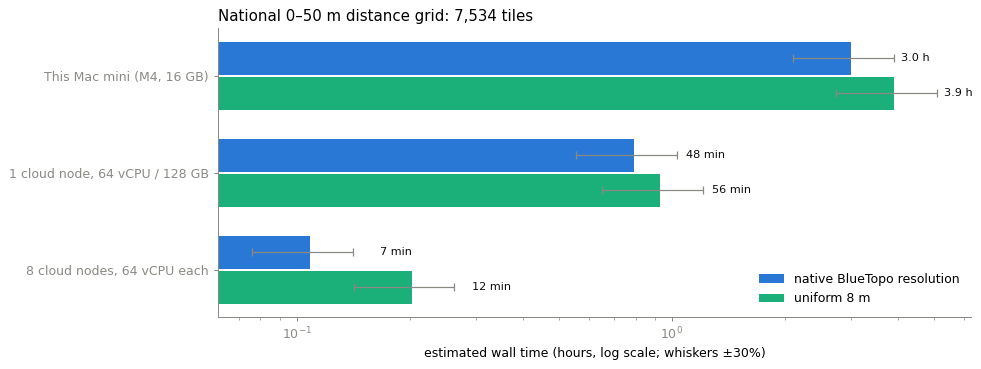

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.2))
machines = [m[0] for m in MACHINES]
y = np.arange(len(machines))
for k, (scen, color) in enumerate((("native BlueTopo resolution", BLUE), ("uniform 8 m", AQUA))):
    sub = est[est.output == scen].set_index("machine").loc[machines]
    yy = y + (k - 0.5) * 0.36
    ax.barh(yy, sub.total_h, height=0.34, color=color, label=scen)
    ax.errorbar(sub.total_h, yy, xerr=[sub.total_h * 0.3, sub.total_h * 0.3], fmt="none", ecolor=MUTED, lw=1, capsize=3)
    for v, yv in zip(sub.total_h, yy):
        ax.text(v * 1.35 + 0.02, yv, f"{v:,.1f} h" if v >= 1 else f"{v*60:,.0f} min", va="center", fontsize=9, color=INK)
ax.set_yticks(y); ax.set_yticklabels(machines); ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel("estimated wall time (hours, log scale; whiskers ±30%)")
ax.set_title(f"National 0–{MAX_DEPTH_M} m distance grid: {len(plan):,} tiles", loc="left")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.savefig(OUT_DIR / "plan_time_estimate.png", dpi=120, bbox_inches="tight"); plt.show()

## 7. Tile manifest

The run plan as a GeoPackage, one row per tile: id, region, source, resolution, UTM zone, footprint, pixel counts, and the
estimated seconds on this Mac. A production run can work through it largest-first (best for load balancing) and record
which tiles are done.

In [13]:
plan["est_s_this_mac"] = plan.px_native / per_thread
plan["est_working_GB"] = plan.px_native * WORKING_BYTES_PER_PX / 1e9
manifest = gpd.GeoDataFrame(plan, geometry=[shapely.box(a, b, c if c > a else c + 360, d)
                                             for a, b, c, d in zip(plan.lon0, plan.lat0, plan.lon1, plan.lat1)],
                            crs="EPSG:4326").sort_values("px_native", ascending=False)
MANIFEST = OUT_DIR / f"tile_manifest_0-{MAX_DEPTH_M}m.gpkg"
manifest.to_file(MANIFEST, layer="tiles", driver="GPKG")
cusp.rename_axis("cusp_package").reset_index().to_csv(OUT_DIR / "cusp_packages.csv", index=False)
est.to_csv(OUT_DIR / "time_estimate.csv", index=False)
print(f"{MANIFEST}: {len(manifest):,} tiles")
manifest.drop(columns="geometry").head(8)

outputs/plan/tile_manifest_0-50m.gpkg: 7,534 tiles


,tile,region,source,res,utm,lon0,lat0,lon1,lat1,zone_cells,px_native,px_8m,est_s_this_mac,est_working_GB
18,BC25Z26L,CONUS + Great Lakes,BlueTopo (delivered),16.0,17,-84.0,25.2,-82.8,26.4,1069,64975131,259610085,93.318874,1.429453
6,BC25X26N,CONUS + Great Lakes,BlueTopo (delivered),16.0,16,-85.2,27.6,-84.0,28.8,1411,63831784,255022182,91.676771,1.404299
29,BC25Q26N,CONUS + Great Lakes,BlueTopo (delivered),16.0,15,-92.4,27.6,-91.2,28.8,1454,62545576,249880400,89.829488,1.376003
27,BC25N26N,CONUS + Great Lakes,BlueTopo (delivered),16.0,15,-94.8,27.6,-93.6,28.8,2133,62545576,249880400,89.829488,1.376003
32,BC26526P,CONUS + Great Lakes,BlueTopo (delivered),16.0,17,-80.4,28.8,-79.2,30.0,588,61887940,247268035,88.884975,1.361535
35,BC26626R,CONUS + Great Lakes,BlueTopo (delivered),16.0,17,-79.2,31.2,-78.0,32.4,56,61883485,247235436,88.878577,1.361437
28,BC25P26N,CONUS + Great Lakes,BlueTopo (delivered),16.0,15,-93.6,27.6,-92.4,28.8,1590,61711397,246545740,88.631420,1.357651
33,BC26526Q,CONUS + Great Lakes,BlueTopo (delivered),16.0,17,-80.4,30.0,-79.2,31.2,1176,61211912,244550796,87.914047,1.346662


## 8. Recommended run plan

1. **Group tiles by CUSP 5° region.** For each group, build one shoreline index from the region plus its neighbours. Use a
   buffer of 1.25 × the largest zone distance for that region from section 2, rounded up. This keeps Alaska's very long
   coastline in memory one region at a time.
2. **Within a group**, run tiles largest-first on a thread pool (as in the mosaic notebook). Cap the number running at once by
   memory (`est_working_GB`).
3. **Resume-safe:** skip tiles whose output GeoTIFF already exists, and log failures to the manifest.
4. **Check as you go:** assert max distance < buffer for every tile, compare tile overlaps (same as the seam check), and run a
   KD-tree spot check on random pixels in each region.
5. **Deliver** per-tile GeoTIFFs (native grids) plus one mosaic (VRT or GeoTIFF with overviews) per UTM zone. Mosaics can't
   cross zones without resampling.

**Caveats**
* ETOPO at 1′ (about 1.85 km) decides which tiles are in; the actual distances still come from 2 m-densified CUSP lines. Narrow
  shallow features below 1′ can be missed. Lower `ETOPO_STRIDE` to 2 or 1 for a finer cut.
* CUSP is a **US** shoreline. Near the borders (Canada, Mexico, Bahamas, Russia) distances are to the nearest *US* shore.
* Synthetic cells follow BlueTopo's 0.3° pattern but are not official BlueTopo grids. Recompute them when BlueTopo delivers real tiles.
* Times for other machines are assumed. Measure them with the calibration cell below.

In [14]:
# Optional: measure throughput on the machine that will do the run (about 1 minute; uses the cached Gulf data).
RUN_CALIBRATION = False
if RUN_CALIBRATION:
    import rasterio
    sd.warmup()
    with rasterio.open(next((DATA_DIR / "bluetopo").glob("BlueTopo_BF2GS2KS_*.tiff"))) as ds:
        T, shp, b = ds.transform, ds.shape, ds.bounds
    box = (b.left - 30000, b.bottom - 30000, b.right + 30000, b.top + 30000)
    idx = sd.ShorelineIndex.build(sd.load_cusp(box, "EPSG:26916", DATA_DIR))
    t0 = time.perf_counter(); sd.distance_on_grid(idx, T, shp); dt = time.perf_counter() - t0
    print(f"one tile alone: {shp[0]*shp[1]/dt/1e6:.2f} Mpx/s per thread (this Mac measured {MEASURED['single_tile_px']/MEASURED['single_tile_s']/1e6:.2f})")